In [1]:
import pandas as pd
import numpy as np
import iisignature
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics.pairwise import rbf_kernel
import matplotlib.pyplot as plt
from datetime import datetime
import yfinance as yf


def compute_mmd(X: np.ndarray, Y: np.ndarray, sigma: float = None) -> float:
    """
    Compute the unbiased MMD (RBF kernel) between two sample sets.
    """
    Z = np.vstack([X, Y])
    if sigma is None:
        dists = np.sum((Z[:, None, :] - Z[None, :, :])**2, axis=2)
        sigma = np.sqrt(0.5 * np.median(dists[dists > 0]))
    gamma = 1.0 / (2 * sigma**2)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    m, n = X.shape[0], Y.shape[0]
    mmd = (np.sum(Kxx) - np.trace(Kxx)) / (m * (m - 1)) \
        + (np.sum(Kyy) - np.trace(Kyy)) / (n * (n - 1)) \
        - 2 * np.mean(Kxy)
    return mmd


def get_sub_paths(df: pd.DataFrame, window: int) -> np.ndarray:
    """
    Extract multidimensional path segments from an OHLCV DataFrame using a sliding window.
    Returns shape: (n_subpaths, window, 3)
    Features: log returns, volume change rate, and range ratio.
    """
    # Ensure arrays are one-dimensional
    close = df['Close'].astype(float).values.squeeze()
    volume = df['Volume'].astype(float).values.squeeze()
    high = df['High'].astype(float).values.squeeze()
    low = df['Low'].astype(float).values.squeeze()

    # Base features
    log_ret = np.r_[0.0, np.diff(np.log(close))]
    vol_change = np.r_[0.0, np.diff(volume) / volume[:-1]]
    range_ratio = (high - low) / df['Open'].astype(float).values.squeeze()

    N = len(close)
    paths = []
    for i in range(N - window + 1):
        seg = np.vstack([
            log_ret[i:i+window],
            vol_change[i:i+window],
            range_ratio[i:i+window]
        ]).T  # shape: (window, 3)
        paths.append(seg)
    return np.array(paths)


def get_grouped_paths(paths: np.ndarray, group_size: int) -> np.ndarray:
    """
    Group subpaths into larger batches for MMD evaluation.
    """
    n_sub = paths.shape[0]
    n_groups = n_sub // group_size
    trimmed = paths[:n_groups * group_size]
    return trimmed.reshape(n_groups, group_size, *paths.shape[1:])


class SignatureBasedRegimeClustering:
    def __init__(
        self,
        window_size=7,
        sig_depth=3,
        cluster_methods=None,
        mmd_subpath_size=7,
        mmd_group_size=50
    ):
        self.window_size = window_size
        self.sig_depth = sig_depth
        self.cluster_methods = cluster_methods or ['kmeans', 'dbscan', 'gmm']
        self.mmd_subpath_size = mmd_subpath_size
        self.mmd_group_size = mmd_group_size
        self.models = {}
        self.labels = {}
        self.scores = {}

    def _prepare_paths(self, df: pd.DataFrame):
        return get_sub_paths(df, self.window_size)

    def _compute_signatures(self, paths: np.ndarray):
        depth = self.sig_depth
        return np.stack([iisignature.sig(p, depth) for p in paths], axis=0)

    def _evaluate_mmd(self, df: pd.DataFrame):
        sub = get_sub_paths(df, self.mmd_subpath_size)
        feats = self._compute_signatures(sub)
        groups = get_grouped_paths(feats, self.mmd_group_size)
        G = groups.shape[0]
        if G < 2:
            return np.nan
        ms = []
        for i in range(G - 1):
            ms.append(compute_mmd(groups[i], groups[i+1]))
        return float(np.mean(ms))

    def fit(self, df: pd.DataFrame):
        paths = self._prepare_paths(df)
        feats = self._compute_signatures(paths)
        mu, sd = feats.mean(0), feats.std(0)
        sd[sd==0]=1.0
        X = (feats - mu) / sd
        for m in self.cluster_methods:
            if m=='kmeans':
                model=KMeans(n_clusters=3,random_state=0)
                lbls=model.fit_predict(X)
            elif m=='dbscan':
                model=DBSCAN(eps=0.5,min_samples=5)
                lbls=model.fit_predict(X)
            elif m=='gmm':
                model=GaussianMixture(n_components=3,random_state=0)
                lbls=model.fit_predict(X)
            else:
                continue
            score=self._evaluate_mmd(df)
            self.models[m]=model
            self.labels[m]=lbls
            self.scores[m]=score
        return self

    def get_labels_series(self, dates, method):
        if method not in self.labels:
            raise ValueError(method)
        end=dates[self.window_size-1:]
        return pd.Series(self.labels[method],index=end)

    def describe_clusters(self, df, method):
        subs=get_sub_paths(df,self.window_size)
        crs=np.array([np.exp(s[:,0].sum())-1 for s in subs])
        vols=np.array([s[:,0].std() for s in subs])
        rngs=np.array([s[:,2].mean() for s in subs])
        stats=[]
        for lbl in sorted(np.unique(self.labels[method])):
            mask=self.labels[method]==lbl
            stats.append({
                'cluster':lbl,
                'count':int(mask.sum()),
                'avg_cum_return':crs[mask].mean(),
                'avg_volatility':vols[mask].mean(),
                'avg_range_ratio':rngs[mask].mean()
            })
        dfst=pd.DataFrame(stats)
        print(dfst.to_string(index=False, float_format='%.4f'))
        return dfst


if __name__=='__main__':
    # Load BTC data from yfinance starting from 2020
    btc=yf.download('BTC-USD',start='2020-01-01',end=datetime.today().strftime('%Y-%m-%d'),
                     interval='1d',progress=False,threads=False)
    btc=btc[['Open','High','Low','Close','Volume']].dropna()

    clustering=SignatureBasedRegimeClustering(
        window_size=30,
        sig_depth=3,
        cluster_methods=['kmeans'],
        mmd_subpath_size=7,
        mmd_group_size=30
    )
    clustering.fit(btc)
    print("MMD scores:")
    for m,s in clustering.scores.items(): print(f"  {m}: {s:.4f}")
    best=max(clustering.scores,key=lambda k:clustering.scores[k] if not np.isnan(clustering.scores[k]) else -np.inf)
    print("Best by MMD:",best)
    ls=clustering.get_labels_series(btc.index,best)
    clustering.describe_clusters(btc,best)


/var/folders/pt/0nf2m3pj1f3b373wsyfc6glh0000gn/T/ipykernel_90432/2648891020.py:160: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc=yf.download('BTC-USD',start='2020-01-01',end=datetime.today().strftime('%Y-%m-%d'),
/Users/zheguan/.pyenv/versions/3.10.13/lib/python3.10/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


MMD scores:
  kmeans: -0.0045
Best by MMD: kmeans
 cluster  count  avg_cum_return  avg_volatility  avg_range_ratio
       0    309          0.0242          0.0333           0.0474
       1     28         -0.3085          0.0979           0.0829
       2   1652          0.0709          0.0283           0.0414


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.
*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2-D array with a single row if you intend to specify the same RGB or RGBA value for all points.


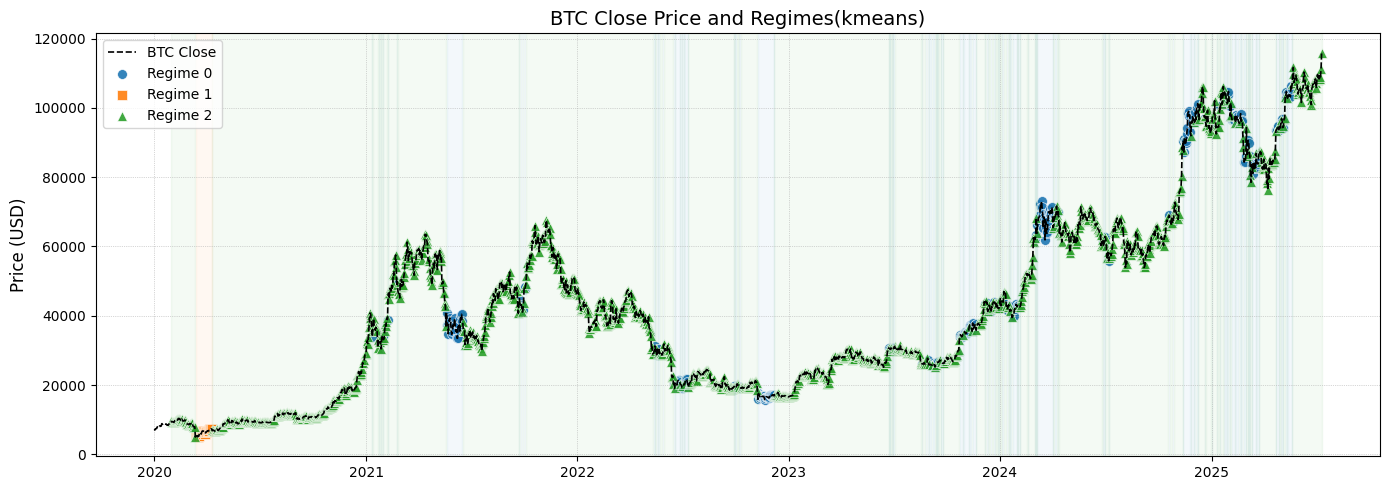

In [2]:
subset = btc.loc['2020-01-01':]
price = subset['Close']

labels_series = clustering.get_labels_series(subset.index, best)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(price.index, price.values,
        linestyle='--', color='black', linewidth=1.2, label='BTC Close')

labels = sorted(labels_series.unique())
n = len(labels)

all_markers = ['o','s','^','d','v','x','*','P','h']  # 至少 n 个
all_colors  = plt.cm.tab10.colors                     # 最多 10 色，你也可以用 cm.tab20

marker_map = {lbl: all_markers[i % len(all_markers)] for i, lbl in enumerate(labels)}
color_map  = {lbl: all_colors [i % len(all_colors )] for i, lbl in enumerate(labels)}

for lbl in sorted(labels_series.unique()):
    sub = labels_series[labels_series == lbl]
    sub_dates = sub.index
    sub_prices = price.loc[sub_dates]
    ax.scatter(sub_dates, sub_prices,
               s=50, marker=marker_map[lbl],
               c=color_map[lbl], edgecolor='white', linewidth=0.5,
               alpha=0.9, label=f'Regime {lbl}')

# 背景色块标注 regime 区段
for lbl in sorted(labels_series.unique()):
    vals = (labels_series == lbl).astype(int).to_numpy()
    changes = np.diff(np.concatenate(([0], vals, [0])))
    starts = np.where(changes == 1)[0]
    ends = np.where(changes == -1)[0]
    for st, ed in zip(starts, ends):
        start_date = labels_series.index[st]
        end_date = labels_series.index[ed-1]
        ax.axvspan(start_date, end_date,
                   color=color_map[lbl], alpha=0.05)

ax.set_title(f'BTC Close Price and Regimes({best})', fontsize=14)
ax.set_ylabel('Price (USD)', fontsize=12)
ax.legend(loc='upper left', facecolor='white', framealpha=0.8)
ax.grid(True, linestyle=':', linewidth=0.5)
plt.tight_layout()
plt.show()